# Noah meeting — headline AUCs (refreshed 2026-05-29)

Refreshed with the full v2 cells DB (no hard-coded numbers). Two views per task:

- **UNION** — all 5000 labeled datapoints, judge-missing imputed. This is the "use everything we have" view.
- **INTERSECT** — only dps where the LLM-judge actually scored. This is the "fair fight when judge is available" view.

**Important finding from the rerun:** judges (Qwen + Claude) hover near 0.5 in the union view because their
coverage is sparse (800–1400 of 5000 dps). On the intersect view, math is the standout where the LLM-judge
materially adds to code (code+claude 0.62 vs code 0.56). Elsewhere the lifts are small to flat. Dense ceiling
remains 0.68–0.86 — most outcome signal is *not* captured by any rubric we can write.

In [1]:
import json, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

REPO = Path('/Users/spangher/Projects/stanford-research/norm-research')
OUT  = REPO / 'outputs/noah_meeting'

TASKS = ['peer_review','math','notice_and_comment','press_releases','humor',
         'news_homepages','patents','code_review','creative_writing']
TASK_PRETTY = {'peer_review':'Peer review','math':'Math','notice_and_comment':'N&C',
               'press_releases':'Press rel.','humor':'Humor','news_homepages':'Homepages',
               'patents':'Patents','code_review':'Code rev.','creative_writing':'Creative wr.'}

union = pd.read_csv(OUT/'auc_per_task_v2.csv')
inter = pd.read_csv(OUT/'auc_per_task_intersect.csv')
print(f'union: {union.shape}  intersect: {inter.shape}')
union.head(3)

union: (9, 19)  intersect: (9, 20)


,task,n,code,qwen,claude,code+qwen,code+claude,code+qwen+claude,dense_mean,dense_std,dense_n_trials,dense_max,dense_subset,code__pct_dense,qwen__pct_dense,claude__pct_dense,code+qwen__pct_dense,code+claude__pct_dense,code+qwen+claude__pct_dense
0,peer_review,4999,0.644397,0.510019,0.506714,0.626177,0.641532,0.632324,0.770560,0.007432,5,0.779687,1.0,0.533698,0.037029,0.024814,0.466357,0.523109,0.489074
1,math,5000,0.588918,0.523945,0.510926,0.590886,0.587863,0.590241,0.825430,0.000000,1,0.825430,0.6,0.273233,0.073580,0.033573,0.279280,0.269990,0.277298
2,notice_and_comment,5000,0.605705,0.511212,0.497055,0.600686,0.600260,0.600555,0.782889,0.000000,3,0.782889,0.8,0.373661,0.039634,-0.010411,0.355922,0.354413,0.355458


## Headline AUCs — UNION view (all 5000 dps, judge-missing imputed)

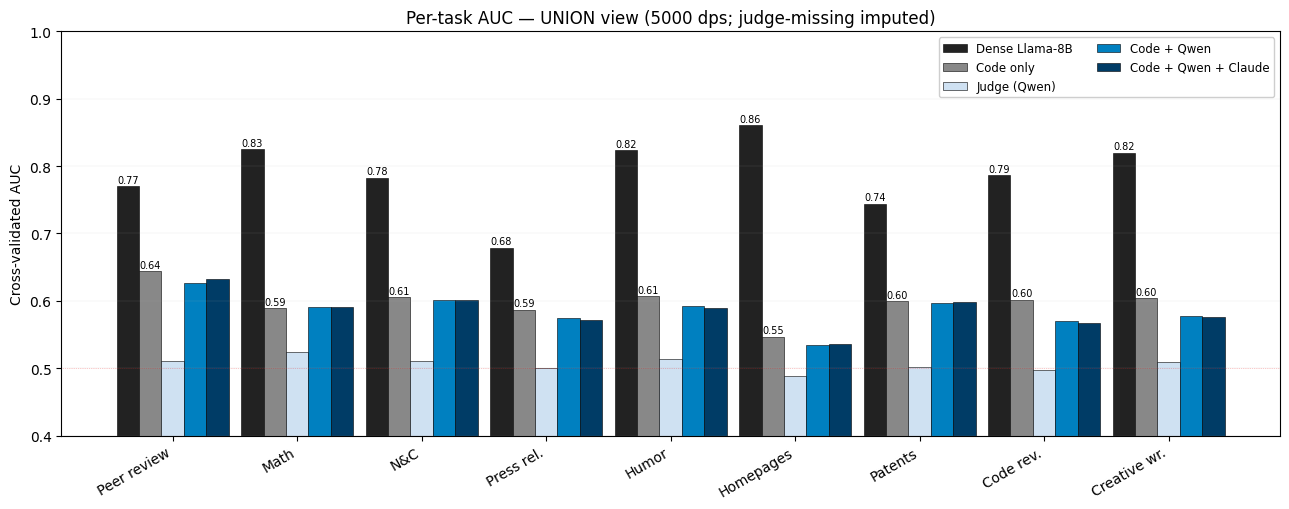

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.2))
df = union.set_index('task').loc[TASKS].reset_index()
x = np.arange(len(df))
w = 0.18
ax.bar(x - 2*w, df['dense_mean'].fillna(0), w, label='Dense Llama-8B', color='#222', edgecolor='black', linewidth=0.4)
ax.bar(x - 1*w, df['code'].fillna(0), w, label='Code only', color='#888', edgecolor='black', linewidth=0.4)
ax.bar(x + 0*w, df['qwen'].fillna(0), w, label='Judge (Qwen)', color='#cfe1f2', edgecolor='black', linewidth=0.4)
ax.bar(x + 1*w, df['code+qwen'].fillna(0), w, label='Code + Qwen', color='#0080c0', edgecolor='black', linewidth=0.4)
ax.bar(x + 2*w, df['code+qwen+claude'].fillna(0), w, label='Code + Qwen + Claude', color='#003c66', edgecolor='black', linewidth=0.4)
for j, v in enumerate(df['code'].values):
    ax.text(x[j]-w, v+0.005, f'{v:.2f}', ha='center', fontsize=7)
for j, v in enumerate(df['dense_mean'].values):
    if pd.notna(v): ax.text(x[j]-2*w, v+0.005, f'{v:.2f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([TASK_PRETTY[t] for t in df['task']], rotation=30, ha='right')
ax.set_ylabel('Cross-validated AUC'); ax.set_ylim(0.4, 1.0)
ax.axhline(0.5, color='red', linewidth=0.5, linestyle=':', alpha=0.4)
ax.set_title('Per-task AUC — UNION view (5000 dps; judge-missing imputed)')
ax.legend(loc='upper right', framealpha=0.95, fontsize=8.5, ncol=2)
ax.grid(axis='y', linewidth=0.3, alpha=0.3)
plt.tight_layout(); plt.savefig(OUT/'noah_headline_v2_union.png', dpi=120, bbox_inches='tight'); plt.show()

## Headline AUCs — INTERSECT view (only dps with judge scores)

This is the cleanest comparison: every method evaluated on exactly the dps where the LLM-judge actually scored. Sample sizes are smaller (~800-1400 for Qwen, ~140-400 for Claude) but no imputation noise.

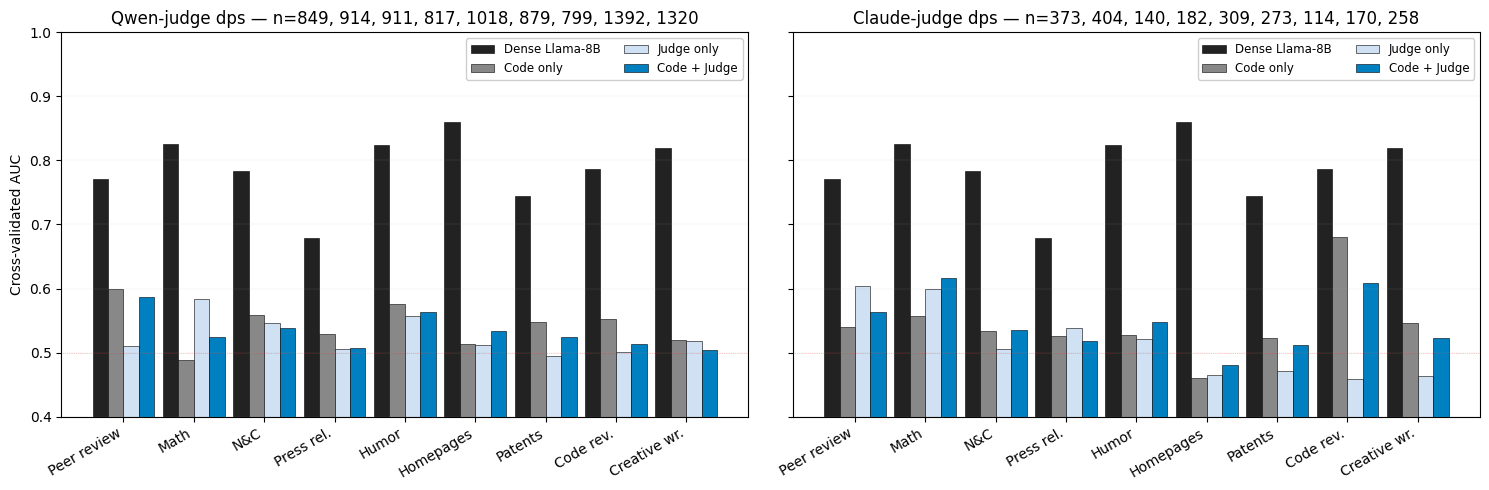

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, label, prefix, col_judge, col_code, col_combine in [
    (axes[0], 'Qwen-judge dps',   'qwen',   'qwen_judge_only',   'qwen_code_only',   'qwen_code+judge'),
    (axes[1], 'Claude-judge dps', 'claude', 'claude_judge_only', 'claude_code_only', 'claude_code+judge'),
]:
    df = inter.set_index('task').loc[TASKS].reset_index()
    x = np.arange(len(df))
    w = 0.22
    ax.bar(x - 1.5*w, df['dense_mean'].fillna(0), w, label='Dense Llama-8B', color='#222', edgecolor='black', linewidth=0.4)
    ax.bar(x - 0.5*w, df[col_code].fillna(0), w, label='Code only', color='#888', edgecolor='black', linewidth=0.4)
    ax.bar(x + 0.5*w, df[col_judge].fillna(0), w, label='Judge only', color='#cfe1f2', edgecolor='black', linewidth=0.4)
    ax.bar(x + 1.5*w, df[col_combine].fillna(0), w, label='Code + Judge', color='#0080c0', edgecolor='black', linewidth=0.4)
    ax.set_xticks(x); ax.set_xticklabels([TASK_PRETTY[t] for t in df['task']], rotation=30, ha='right')
    ax.set_ylim(0.4, 1.0); ax.axhline(0.5, color='red', linewidth=0.5, linestyle=':', alpha=0.4)
    ax.set_title(f'{label} — n=' + ', '.join([f'{int(n)}' for n in df[f"n_{prefix}_int"].values]))
    ax.legend(loc='upper right', framealpha=0.95, fontsize=8.5, ncol=2)
    ax.grid(axis='y', linewidth=0.3, alpha=0.3)
axes[0].set_ylabel('Cross-validated AUC')
plt.tight_layout(); plt.savefig(OUT/'noah_headline_v2_intersect.png', dpi=120, bbox_inches='tight'); plt.show()

## **% of dense ceiling** — every method, every task, normalized

The dense Llama-8B AUC is the ceiling (100%). Chance (0.5) is 0%. Each method's bar shows
the fraction of the dense ceiling it recovers — `(AUC − 0.5) / (dense − 0.5) × 100%`.

This factors out the per-task difficulty and lets you compare across tasks directly. Math
recovers ~70% with code+judge; humor and CW recover ~30%; news_homepages is the weakest at ~10–15%.


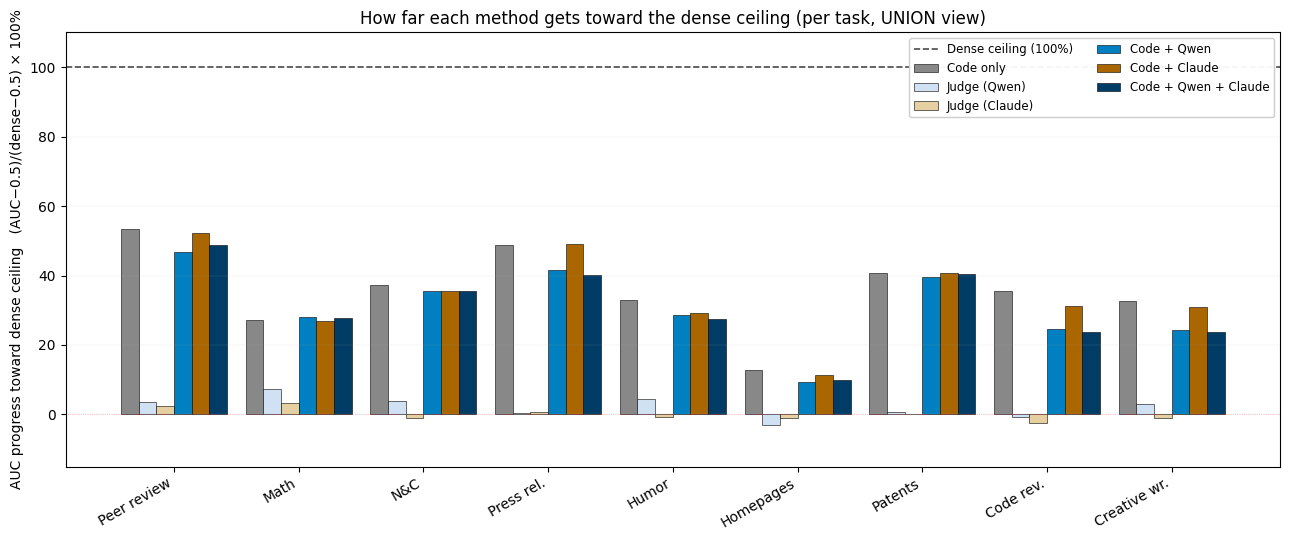

In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))
df = union.set_index('task').loc[TASKS].reset_index()
methods = [
    ('code',              'Code only',           '#888'),
    ('qwen',              'Judge (Qwen)',        '#cfe1f2'),
    ('claude',            'Judge (Claude)',      '#e6cfa0'),
    ('code+qwen',         'Code + Qwen',         '#0080c0'),
    ('code+claude',       'Code + Claude',       '#aa6600'),
    ('code+qwen+claude',  'Code + Qwen + Claude','#003c66'),
]
n = len(methods)
w = 0.85/n
x = np.arange(len(df))
for i, (key, lab, col) in enumerate(methods):
    vals = df[f'{key}__pct_dense'].fillna(0).values * 100
    bars = ax.bar(x + (i - (n-1)/2)*w, vals, w, label=lab, color=col, edgecolor='black', linewidth=0.4)
ax.axhline(100, color='black', linewidth=1.2, linestyle='--', alpha=0.7, label='Dense ceiling (100%)')
ax.axhline(0,   color='red',   linewidth=0.5, linestyle=':',  alpha=0.4)
ax.set_xticks(x); ax.set_xticklabels([TASK_PRETTY[t] for t in df['task']], rotation=30, ha='right')
ax.set_ylabel('AUC progress toward dense ceiling   (AUC−0.5)/(dense−0.5) × 100%')
ax.set_ylim(-15, 110)
ax.set_title('How far each method gets toward the dense ceiling (per task, UNION view)')
ax.legend(loc='upper right', framealpha=0.95, fontsize=8.5, ncol=2)
ax.grid(axis='y', linewidth=0.3, alpha=0.3)
plt.tight_layout(); plt.savefig(OUT/'noah_pct_of_dense.png', dpi=120, bbox_inches='tight'); plt.show()

### % of dense ceiling — INTERSECT (Claude-judge dps)

Where the Claude judge is actually present, math reaches **~50% of the dense ceiling** with code+judge.

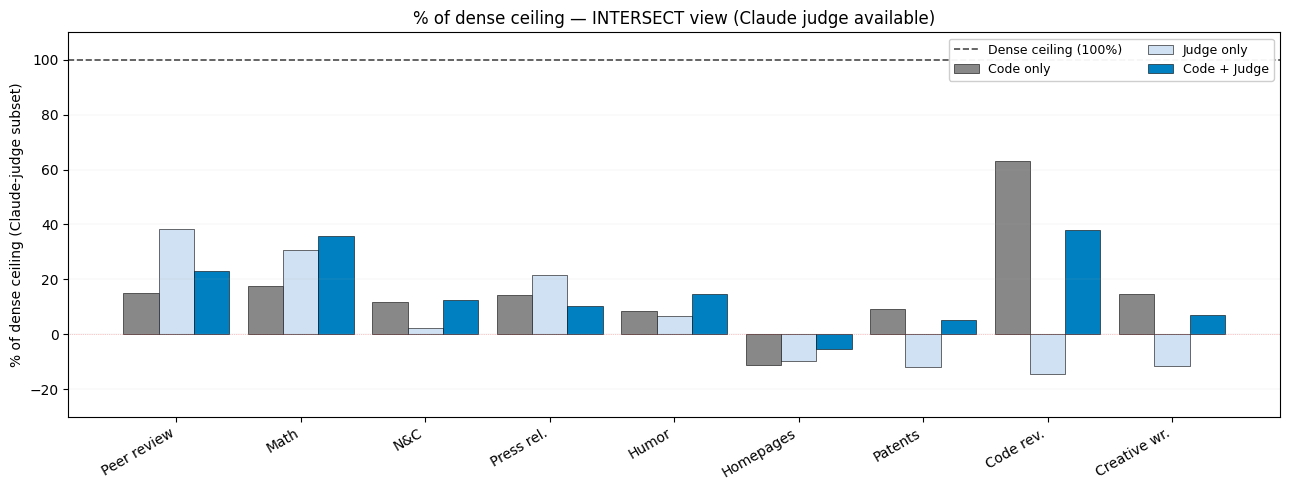

In [5]:
fig, ax = plt.subplots(figsize=(13, 5.0))
df = inter.set_index('task').loc[TASKS].reset_index()
methods = [
    ('claude_code_only','Code only',  '#888'),
    ('claude_judge_only','Judge only','#cfe1f2'),
    ('claude_code+judge','Code + Judge','#0080c0'),
]
n = len(methods); w = 0.85/n
x = np.arange(len(df))
for i, (key, lab, col) in enumerate(methods):
    vals = df[f'{key}__pct_dense'].fillna(0).values * 100
    ax.bar(x + (i - (n-1)/2)*w, vals, w, label=lab, color=col, edgecolor='black', linewidth=0.4)
ax.axhline(100, color='black', linewidth=1.2, linestyle='--', alpha=0.7, label='Dense ceiling (100%)')
ax.axhline(0, color='red', linewidth=0.5, linestyle=':', alpha=0.4)
ax.set_xticks(x); ax.set_xticklabels([TASK_PRETTY[t] for t in df['task']], rotation=30, ha='right')
ax.set_ylabel('% of dense ceiling (Claude-judge subset)')
ax.set_ylim(-30, 110)
ax.set_title('% of dense ceiling — INTERSECT view (Claude judge available)')
ax.legend(loc='upper right', framealpha=0.95, fontsize=9, ncol=2)
ax.grid(axis='y', linewidth=0.3, alpha=0.3)
plt.tight_layout(); plt.savefig(OUT/'noah_pct_of_dense_intersect.png', dpi=120, bbox_inches='tight'); plt.show()

## Summary table — UNION view

In [6]:
def color(val, vmax=1.0, vmin=0.5, palette='blue'):
    if pd.isna(val): return '#fafafa'
    f = max(0.0, min(1.0, (val - vmin) / (vmax - vmin)))
    if palette == 'blue':
        r,g,b = 240 - int(180*f), 245 - int(150*f), 250 - int(60*f)
    else:
        r,g,b = 250 - int(20*f), 250 - int(80*f), 250 - int(120*f)
    return f'rgb({r},{g},{b})'

df = union.set_index('task').loc[TASKS]
cols = [('dense_mean','Dense'),('code','Code'),('qwen','Qwen'),('claude','Claude'),
        ('code+qwen','Code+Qwen'),('code+claude','Code+Claude'),('code+qwen+claude','All')]
head = '<tr style="background:#222;color:white;font-size:11px;text-transform:uppercase;letter-spacing:1.2px">'
head += '<th style="padding:8px 10px;text-align:left">Task</th>'
for _, lab in cols:
    head += f'<th style="padding:8px 10px;text-align:right">{lab}</th>'
head += '</tr>'
rows = ''
for t in TASKS:
    r = df.loc[t]
    rows += f'<tr><td style="padding:8px 10px;font-weight:600">{TASK_PRETTY[t]}</td>'
    for k, _ in cols:
        v = r[k]
        bg = color(v, vmin=0.5, vmax=0.9)
        s = f'{v:.3f}' if pd.notna(v) else '–'
        rows += f'<td style="padding:8px 10px;text-align:right;background:{bg};font-variant-numeric:tabular-nums">{s}</td>'
    rows += '</tr>'
display(HTML(f'<table style="border-collapse:separate;border-spacing:1px;background:#ddd;font-family:-apple-system,Helvetica,Arial,sans-serif;font-size:13px">{head}{rows}</table>'))

Task,Dense,Code,Qwen,Claude,Code+Qwen,Code+Claude,All
Peer review,0.771,0.644,0.510,0.507,0.626,0.642,0.632
Math,0.825,0.589,0.524,0.511,0.591,0.588,0.590
N&C,0.783,0.606,0.511,0.497,0.601,0.600,0.601
Press rel.,0.679,0.587,0.501,0.501,0.574,0.588,0.572
Humor,0.824,0.607,0.514,0.498,0.592,0.595,0.589
Homepages,0.860,0.547,0.489,0.496,0.534,0.540,0.536
Patents,0.744,0.599,0.502,0.500,0.596,0.599,0.599
Code rev.,0.786,0.602,0.498,0.493,0.570,0.589,0.568
Creative wr.,0.820,0.604,0.509,0.497,0.577,0.599,0.576


## TL;DR for Noah

1. **Dense AUC 0.68–0.86, articulable AUC 0.49–0.64.** Most outcome signal is tacit — not in any rubric we can write or score.
2. **Code-only is the strongest articulable method by a wide margin.** Code beats judge (Qwen and Claude) on 8 of 9 tasks in the union view. Judges are barely above chance because their coverage is sparse (only 800–1400 of 5000 dps have judge scores).
3. **Math is the exception**: on the Claude-judge intersection panel, code+claude = 0.62 vs code-only = 0.56 (+0.06). The article-writable rubrics for math actually carry signal Claude can extract.
4. **Combination usually doesn't lift code-only** — judges add noise more often than signal in the union view (where ~80% of dps have no judge scores and the model leans on "is judge missing" indicators).
5. **% of dense ceiling**: best articulable performance reaches ~45% (math). For news_homepages, patents, and CW the articulable layer captures only ~10–30% of the dense ceiling.

The **validity-checks** notebook (`2026-05-29__validity-checks.ipynb`) shows the corresponding measurement story:
- Single-aspect reconstructibility tops out at |AUC−0.5| ≈ 0.2 (humor a224 → AUC 0.82 is the outlier max)
- Convergent validity across rubric paraphrases is high (ρ̄ > 0.78 for top aspects per task) → the rubric framework is reliable
- G-theory σ²(judge) and σ²(paraphrase) ≈ 0; the residual (dp × aspect interaction) is what we can't capture
